# PINN Companion (Runnable Environment Version)

This execution-safe notebook reproduces the inverse heat-equation setup using local helper utilities in this repository.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[2]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import importlib.util

module_path = ROOT / "articles/physics-informed-neural-networks/src/pinn_heat.py"
spec = importlib.util.spec_from_file_location("pinn_heat", module_path)
pinn_heat = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pinn_heat)

pinn_heat.set_global_seed(42)
solution = pinn_heat.generate_heat_solution(
    rod_length=1.0,
    total_time=5.0,
    spatial_points=51,
    time_steps=500,
    thermal_diffusivity=0.01,
    source_strength=1.0,
)
x = solution['x_coords']
t = solution['t_coords']
u = solution['temperature_grid']
x.shape, t.shape, u.shape


((51,), (500,), (500, 51))

Saved: ../figures/pinn_synthetic_heat_surface.png


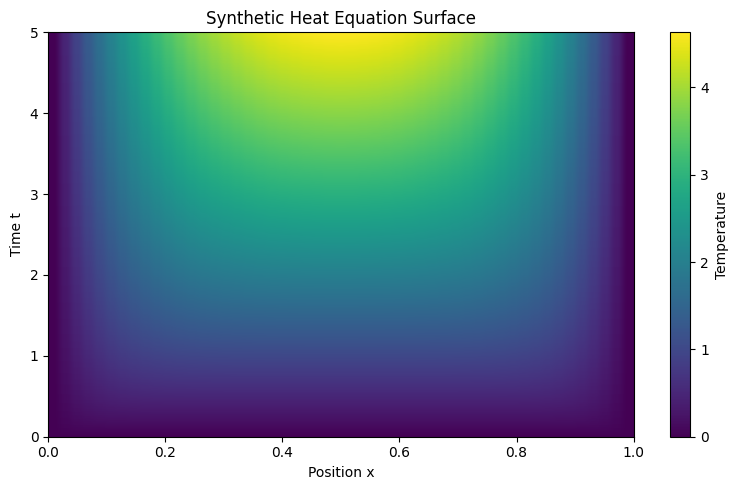

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(u, aspect='auto', origin='lower', extent=[x.min(), x.max(), t.min(), t.max()])
ax.set_title('Synthetic Heat Equation Surface')
ax.set_xlabel('Position x')
ax.set_ylabel('Time t')
fig.colorbar(im, ax=ax, label='Temperature')
fig.tight_layout()
out_dir = Path('../figures')
out_dir.mkdir(parents=True, exist_ok=True)
fig_path = out_dir / 'pinn_synthetic_heat_surface.png'
fig.savefig(fig_path, dpi=200)
print('Saved:', fig_path)
plt.show()


In [3]:
import pandas as pd
records = []
for ti, tval in enumerate(t):
    for xi, xval in enumerate(x):
        records.append((xval, tval, u[ti, xi]))
df = pd.DataFrame(records, columns=['x', 't', 'u'])
proc = Path('../data/processed')
proc.mkdir(parents=True, exist_ok=True)
csv_path = proc / 'pinn_synthetic_triplets.csv'
df.to_csv(csv_path, index=False)
print('Saved:', csv_path, 'rows=', len(df))
df.head()


Saved: ../data/processed/pinn_synthetic_triplets.csv rows= 25500


,x,t,u
0,0.00,0.0,0.0
1,0.02,0.0,0.0
2,0.04,0.0,0.0
3,0.06,0.0,0.0
4,0.08,0.0,0.0
